# Módulo 1 — Pipeline de entrenamiento, validación y clasificador base

**Objetivo:** construir un pipeline de entrenamiento completo en PyTorch — detección de
dispositivo, semillas fijas, training loop explícito con `torch.autograd`, ciclo de
validación separado y registro de métricas por época. La calidad del pipeline es el
entregable; el modelo es deliberadamente simple.

**Dataset:** AG News (el mismo corpus de todo el programa), vectorizado con un TF-IDF
de parámetros por defecto. La optimización del vectorizador (n-gramas, `max_features`)
es objeto del Módulo 3; aquí solo necesitamos una representación numérica estable para
ejercitar el pipeline. Usar el corpus real en lugar de un dataset sintético convierte
esta entrega en el primer eslabón de la cadena del proyecto.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer

from src.config import SEED, DEVICE, FIGURES_DIR, N_CLASSES
from src.dataset import load_raw, train_val_split
from src.train_loop import fit

print(f"PyTorch {torch.__version__} | device: {DEVICE} | seed: {SEED}")

PyTorch 2.14.0 | device: mps | seed: 42


## 1. Carga de datos y split de validación

El split de validación (10%, estratificado) sale **del train**: el test no se toca en
este módulo. La semilla global garantiza que el split sea reproducible.

In [2]:
train_df, test_df = load_raw()
tr_df, val_df = train_val_split(train_df, val_size=0.1)
print(f"train: {len(tr_df):,} | val: {len(val_df):,} | test (reservado): {len(test_df):,}")

train: 7,200 | val: 800 | test (reservado): 2,000


## 2. Vectorización TF-IDF (parámetros por defecto)

In [3]:
vectorizer = TfidfVectorizer(max_features=10_000)
X_tr = vectorizer.fit_transform(tr_df["text"])   # fit SOLO en train
X_val = vectorizer.transform(val_df["text"])
INPUT_DIM = X_tr.shape[1]
print(f"matriz train: {X_tr.shape} | matriz val: {X_val.shape}")

matriz train: (7200, 10000) | matriz val: (800, 10000)


## 3. Dataset y DataLoaders

La matriz TF-IDF es dispersa; densificar las 108k filas de golpe costaría ~4 GB de RAM.
El `Dataset` densifica fila por fila, así cada batch usa memoria constante.

In [4]:
class SparseDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = torch.tensor(y.to_numpy(), dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        row = torch.from_numpy(self.X[i].toarray().squeeze(0)).float()
        return row, self.y[i]


g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(SparseDataset(X_tr, tr_df["label"]), batch_size=256,
                          shuffle=True, generator=g)
val_loader = DataLoader(SparseDataset(X_val, val_df["label"]), batch_size=512)

## 4. Arquitectura

Una capa oculta con ReLU y dropout: suficiente no linealidad para el ejercicio sin
desviar el foco del pipeline.

In [5]:
model = nn.Sequential(
    nn.Linear(INPUT_DIM, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, N_CLASSES),
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
LEARNING_RATE = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)

Sequential(
  (0): Linear(in_features=10000, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=4, bias=True)
)


## 5. Entrenamiento

El loop vive en `src/train_loop.py`: forward → loss → `backward()` → `step()`, con
`optimizer.zero_grad()` en cada iteración y validación bajo `model.eval()` +
`torch.no_grad()`.

In [6]:
EPOCHS = 6
history = fit(model, train_loader, val_loader, criterion, optimizer, EPOCHS)

epoch 1: train 1.3055 | val 1.1383 | F1 0.8813


epoch 2: train 0.9036 | val 0.6776 | F1 0.9068


epoch 3: train 0.4794 | val 0.4158 | F1 0.9083


epoch 4: train 0.2883 | val 0.3302 | F1 0.9083


epoch 5: train 0.2050 | val 0.2989 | F1 0.9109


epoch 6: train 0.1531 | val 0.2821 | F1 0.9122


## 6. Curva de pérdida

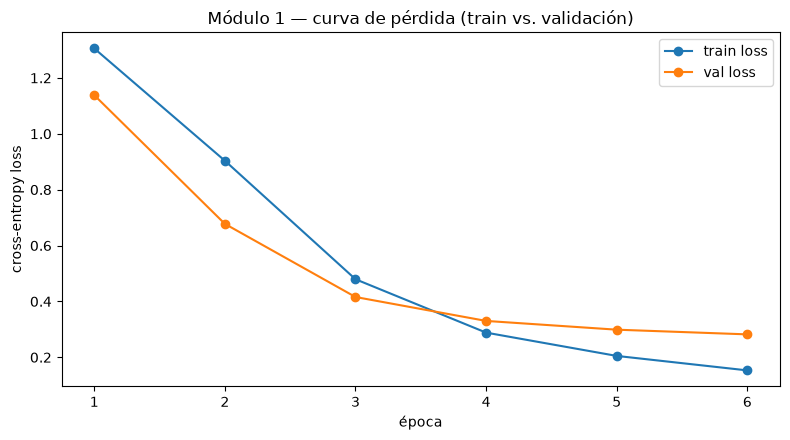

F1 (weighted) final en validación: 0.9122


In [7]:
epochs_axis = np.arange(1, EPOCHS + 1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(epochs_axis, history["train_loss"], marker="o", label="train loss")
ax.plot(epochs_axis, history["val_loss"], marker="o", label="val loss")
ax.set_xlabel("época")
ax.set_ylabel("cross-entropy loss")
ax.set_title("Módulo 1 — curva de pérdida (train vs. validación)")
ax.legend()
fig.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "m1_loss_curve.png", dpi=150)
plt.show()

print(f"F1 (weighted) final en validación: {history['val_f1'][-1]:.4f}")

## 7. Interpretación

**Entorno:** PyTorch 2.14.0 sobre `mps` (GPU Apple Silicon) · `learning_rate = 1e-3` (Adam) · 6 épocas · semilla 42.

Ambas curvas caen de forma monótona: el train loss pasa de 1.31 a 0.15 y el de validación de 1.14 a 0.28. Hasta la época 3 bajan juntas; a partir de la 4 se abre una brecha creciente (0.29 vs 0.21 en la época 5, 0.28 vs 0.15 en la 6) — señal de sobreajuste incipiente que el dropout de 0.3 mantiene contenido, porque el loss de validación **sigue bajando**, no rebota. El F1 (weighted) de validación acompaña: 0.881 en la primera época, 0.908 en la segunda y una meseta alrededor de 0.91 desde la tercera (cierra en 0.9122). Con este learning rate el modelo converge en ~3 épocas y las restantes compran décimas marginales; entrenar más allá de 6 solo ensancharía la brecha train/val sin ganancia real. El objetivo del módulo queda cubierto: un pipeline reproducible con semillas fijas, `zero_grad()` por iteración, validación bajo `model.eval()` + `torch.no_grad()` y métricas registradas por época.